# Multiwell Posterior with mPCN

Generate a 2D dataset from the 16-polynomic wells map and run a basic mPCN chain to estimate $(x_1, x_2)$.

In [11]:
# import os
# import sys
import os
import sys
# from pathlib import Path
import hashlib
import json
from pathlib import Path
import time
from concurrent.futures import ProcessPoolExecutor
from multiprocessing import get_context

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'pyproject.toml').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_path = repo_root / 'src'
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.algorithms.mpcn import mpcn_step, mpcn_chain
from multiproposal.algorithms.pcn import pcn_chain
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size
from multiproposal.problems.toy_custom_likelihood import ToyCustomLikelihood2D
from multiproposal.plotting.diagnostics import make_hist_grid_comps
from multiproposal.utils.run_paths import build_run_dirs, format_float_tag
from reports.figure_style import apply_pub_style


In [12]:
def f_16polynomic_wells(x):
    x1, x2 = x
    comp1 = (x1 ** 2 - 1) * (x1 ** 2 - 4)
    comp2 = (x2 ** 2 - 1) * (x2 ** 2 - 4)
    return np.array([comp1, comp2])

def log_likelihood_16polynomic(x, y_obs, sigma=0.3):
    r = f_16polynomic_wells(x) - y_obs
    return -0.5 * np.dot(r, r) / (sigma ** 2)

## Posterior formulation (16-polynomic wells)

Let $x = (x_1, x_2)^T \in \mathbb{R}^2$. The forward map defined in the code is

$$
f(x) = \begin{bmatrix}
(x_1^2 - 1)(x_1^2 - 4) \\
(x_2^2 - 1)(x_2^2 - 4)
\end{bmatrix}.
$$

The data are generated as

$$
x_{\text{true}} \sim \mathcal{N}(\mu, C), \quad y_{\text{obs}} = f(x_{\text{true}}) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_2),
$$

with $\mu = (0,0)^T$, $C = \text{prior\_std}^2 I_2$ and $\text{prior\_std}=1$ (so $C=I_2$), and $\sigma = \text{sigma\_noise}=1.0$ in this notebook.

The Gaussian likelihood implied by `log_likelihood_16polynomic` is

$$
p(y_{\text{obs}}\mid x) = (2\pi\sigma^2)^{-1}
\exp\left(-\frac{1}{2\sigma^2}\left\|f(x)-y_{\text{obs}}\right\|^2\right).
$$

The prior density is

$$
p(x) = (2\pi)^{-1} |C|^{-1/2}
\exp\left(-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu)\right).
$$

Therefore the posterior is

$$
p(x\mid y_{\text{obs}}) \propto
\exp\left(-\frac{1}{2\sigma^2}\left\|f(x)-y_{\text{obs}}\right\|^2
-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu)\right).
$$

Equivalently, the log-posterior (up to an additive constant) is

$$
\log p(x\mid y_{\text{obs}}) =
-\frac{1}{2\sigma^2}\left\|f(x)-y_{\text{obs}}\right\|^2
-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu) + \text{const}.
$$

In [13]:
# Match the data-generation pattern from the toy notebook
sigma_noise = 1
prior_std = 1
prior_cov = prior_std ** 2 * np.array([[1.0, 0], [0, 1]])
prior_mean = np.zeros(2)

data_seed = 202
rng = np.random.default_rng(data_seed)
prior_sample = rng.multivariate_normal(prior_mean, prior_cov)
theta_true = f_16polynomic_wells(prior_sample)
y_obs = theta_true + rng.normal(0.0, sigma_noise, size=theta_true.shape)

def log_likelihood(x):
    return log_likelihood_16polynomic(x, y_obs, sigma=sigma_noise)

problem = ToyCustomLikelihood2D(
    log_likelihood_fn=log_likelihood,
    prior_mean=prior_mean,
    prior_cov=prior_cov,
)

data_config = {
    'sigma_noise': sigma_noise,
    'prior_std': prior_std,
    'prior_cov': prior_cov.tolist(),
    'prior_mean': prior_mean.tolist(),
    'data_seed': data_seed,
}

print('y_obs:', y_obs)
print('True x:', prior_sample)
print('Log-posterior at prior mean:', problem.log_posterior(prior_mean))

y_obs: [-2.72358526  1.22300603]
True x: [ 1.81172035 -0.72905356]
Log-posterior at prior mean: -26.459147097660278


In [14]:
# MCMC configuration
n_iters = 20000
rho = 0.1
n_props = 20
mess_M = 20
run_mess = True  # Toggle MESS run + plots
run_pcn = True  # Toggle pCN run + plots
num_ind_chains = 20  # Number of independent pCN chains
seed_mcmc = 202
pcn_max_workers = min(num_ind_chains, os.cpu_count() or 1)
pcn_thin_step = max(1, num_ind_chains)

rng_mpcn = np.random.default_rng(seed_mcmc)
rng_mess = np.random.default_rng(seed_mcmc)

# Start at stationarity for mPCN/MESS/first pCN chain
x0 = np.array([-1.5, -0.8], dtype=float)

# pCN starting points (reuse if num_ind_chains > 4, with different seeds)
pcn_start_points = [
    x0.copy(),
    np.array([1.5, 0.8], dtype=float),
    np.array([1.5, -0.8], dtype=float),
    np.array([-1.5, 0.8], dtype=float),
]
pcn_start_points_full = [
    pcn_start_points[i % len(pcn_start_points)].copy()
    for i in range(num_ind_chains)
 ]
pcn_seeds = [seed_mcmc + i for i in range(num_ind_chains)]

# Parallel options for mPCN
n_jobs = None  # None or <=0 uses core_frac cap; 1 disables parallelism
core_frac = 0.7
parallel_backend = "auto"  # "auto" -> threads, "process" for multiprocessing
n_jobs = 4  # None or <=0 uses core_frac cap; 1 disables parallelism
core_frac = 0.7
parallel_backend = "threads"  # "auto" -> threads, "process" for multiprocessing

algo_config = {
    'n_iters': n_iters,
    'rho': rho,
    'n_props': n_props,
    'mess_M': mess_M,
    'run_mess': run_mess,
    'run_pcn': run_pcn,
    'num_ind_chains': num_ind_chains,
    'seed_mcmc': seed_mcmc,
    'pcn_max_workers': pcn_max_workers,
    'pcn_thin_step': pcn_thin_step,
    'n_jobs': n_jobs,
    'core_frac': core_frac,
    'parallel_backend': parallel_backend,
    'x0': x0.tolist(),
}

def format_tag_value(value):
    try:
        value_float = float(value)
    except (TypeError, ValueError):
        return str(value)
    if value_float.is_integer():
        return str(int(value_float))
    return str(value_float).replace('.', 'p')

sigma_tag = format_tag_value(sigma_noise)
prior_tag = format_tag_value(prior_std)
estimations_dir, reports_dir, run_name, run_config = build_run_dirs(
    repo_root,
    dataset='multiwell',
    algorithm='mpcn_single',
    algorithm_dir='',
    data_config=data_config,
    algorithm_config=algo_config,
    tag_parts=[
        f'P{n_props}',
        f'rho{rho}',
        f'iters{n_iters}',
        f'seed{seed_mcmc}',
        f'sigma{sigma_tag}',
        f'prior{prior_tag}',
    ],
)

samples_path = estimations_dir / 'samples.npz'
run_chains = True
if samples_path.exists():
    cached = np.load(samples_path, allow_pickle=False)
    chain_mpcn = cached['chain_mpcn']
    accepted_index = cached['accepted_index']
    chain_pcn = cached['chain_pcn'] if 'chain_pcn' in cached else None
    pcn_chains = cached['pcn_chains'] if 'pcn_chains' in cached else None
    pcn_start_points_full = cached['pcn_start_points_full'] if 'pcn_start_points_full' in cached else pcn_start_points_full
    pcn_seeds = cached['pcn_seeds'] if 'pcn_seeds' in cached else pcn_seeds
    accept_rate_pcn = float(cached['accept_rate_pcn']) if 'accept_rate_pcn' in cached else None
    accept_rate_pcn_all = cached['accept_rate_pcn_all'].tolist() if 'accept_rate_pcn_all' in cached else None
    chain_mess = cached['chain_mess'] if 'chain_mess' in cached else None
    prior_sample = cached['prior_sample'] if 'prior_sample' in cached else prior_sample
    y_obs = cached['y_obs'] if 'y_obs' in cached else y_obs
    runtime_mpcn_sec = float(cached['runtime_mpcn_sec']) if 'runtime_mpcn_sec' in cached else 0.0
    runtime_pcn_sec = float(cached['runtime_pcn_sec']) if 'runtime_pcn_sec' in cached else 0.0
    runtime_mess_sec = float(cached['runtime_mess_sec']) if 'runtime_mess_sec' in cached else 0.0
    accept_rate = np.mean(accepted_index != 0)
    accepted_idx = accepted_index.astype(int)
    run_chains = False
    print('Loaded samples from:', samples_path)

print('Run directory:', estimations_dir)

Loaded samples from: /home/senng/multiproposal-internal/estimations/multiwell/multiwell_mpcn_single_P20_rho0.1_iters20000_seed202_sigma1_prior1_h8f219f464fcc/samples.npz
Run directory: /home/senng/multiproposal-internal/estimations/multiwell/multiwell_mpcn_single_P20_rho0.1_iters20000_seed202_sigma1_prior1_h8f219f464fcc


In [15]:
# mPCN chain
if run_chains:
    t0 = time.perf_counter()
    chain_mpcn, accepted_index = mpcn_chain(
        x0,
        problem,
        rng_mpcn,
        n_iters,
        rho=rho,
        n_props=n_props,
        n_jobs=n_jobs,
        core_frac=core_frac,
        parallel_backend=parallel_backend,
        return_indices=True,
     )
    runtime_mpcn_sec = time.perf_counter() - t0

    accept_rate = np.mean(accepted_index != 0)
    accepted_idx = accepted_index.astype(int)
    print(f'mPCN acceptance rate (state changed): {accept_rate:.3f}')
    print('mPCN accepted indices (first 20):', accepted_idx[:20])
    print(f'mPCN runtime (sec): {runtime_mpcn_sec:.2f}')
else:
    print('Skipping mPCN run (loaded cached samples).')

Skipping mPCN run (loaded cached samples).


In [16]:
# pCN chains (multiprocessing)
def _run_pcn_chain_worker(args):
    chain_idx, seed, x0_chain = args
    rng = np.random.default_rng(seed)
    chain, acc_rate = pcn_chain(
        x0_chain,
        problem,
        rng,
        n_iters,
        rho=rho,
        return_acceptance=True,
    )
    return chain_idx, chain, acc_rate

if run_chains and run_pcn:
    worker_args = [
        (i, pcn_seeds[i], pcn_start_points_full[i].copy())
        for i in range(num_ind_chains)
    ]
    t0 = time.perf_counter()
    if num_ind_chains == 1:
        results = [_run_pcn_chain_worker(worker_args[0])]
    else:
        with ProcessPoolExecutor(
            max_workers=pcn_max_workers,
            mp_context=get_context("fork"),
        ) as executor:
            results = list(executor.map(_run_pcn_chain_worker, worker_args))
    runtime_pcn_sec = time.perf_counter() - t0

    results.sort(key=lambda item: item[0])
    pcn_chains = np.stack([item[1] for item in results], axis=0)
    accept_rate_pcn_all = [float(item[2]) for item in results]
    chain_pcn = pcn_chains[0]
    accept_rate_pcn = accept_rate_pcn_all[0]
    print(f'pCN acceptance rate (chain 0): {accept_rate_pcn:.3f}')
    print('pCN accept rates (all chains):', np.round(accept_rate_pcn_all, 3))
    print(f'pCN runtime (sec): {runtime_pcn_sec:.2f}')
else:
    if run_pcn and not run_chains:
        print('Skipping pCN run (loaded cached samples).')
    else:
        chain_pcn = None
        pcn_chains = None
        accept_rate_pcn = None
        accept_rate_pcn_all = None
        runtime_pcn_sec = 0.0
        print('pCN disabled (run_pcn=False).')

Skipping pCN run (loaded cached samples).


In [17]:
# MESS chain (M=5, no LP)
if run_chains and run_mess:
    chain_mess = np.zeros((n_iters + 1, problem.dim), dtype=float)
    chain_mess[0] = x0
    x = x0.copy()
    t0 = time.perf_counter()
    for t in range(n_iters):
        x, _, _ = mess_step(
            x,
            problem,
            rng_mess,
            M=mess_M,
            use_lp=False,
            distance_metric='angular',
            lam=0.0,
        )
        chain_mess[t + 1] = x
    runtime_mess_sec = time.perf_counter() - t0
    print('MESS run completed.')
    print(f'MESS runtime (sec): {runtime_mess_sec:.2f}')
else:
    if run_mess and not run_chains:
        print('Skipping MESS run (loaded cached samples).')
    else:
        chain_mess = None
        runtime_mess_sec = 0.0
        print('MESS disabled (run_mess=False).')

Skipping MESS run (loaded cached samples).


In [18]:
# Save samples right after the chains finish
run_dir = estimations_dir
if run_chains:
    np.savez_compressed(
        run_dir / 'samples.npz',
        chain_mpcn=chain_mpcn,
        accepted_index=accepted_index,
        chain_pcn=chain_pcn,
        pcn_chains=pcn_chains,
        pcn_start_points_full=np.array(pcn_start_points_full),
        pcn_seeds=np.array(pcn_seeds),
        accept_rate_pcn=accept_rate_pcn,
        accept_rate_pcn_all=accept_rate_pcn_all,
        chain_mess=chain_mess,
        prior_sample=prior_sample,
        y_obs=y_obs,
        runtime_mpcn_sec=runtime_mpcn_sec,
        runtime_pcn_sec=runtime_pcn_sec,
        runtime_mess_sec=runtime_mess_sec,
     )
    print('Saved samples to:', run_dir / 'samples.npz')
else:
    print('Using cached samples at:', run_dir / 'samples.npz')

Using cached samples at: /home/senng/multiproposal-internal/estimations/multiwell/multiwell_mpcn_single_P20_rho0.1_iters20000_seed202_sigma1_prior1_h8f219f464fcc/samples.npz


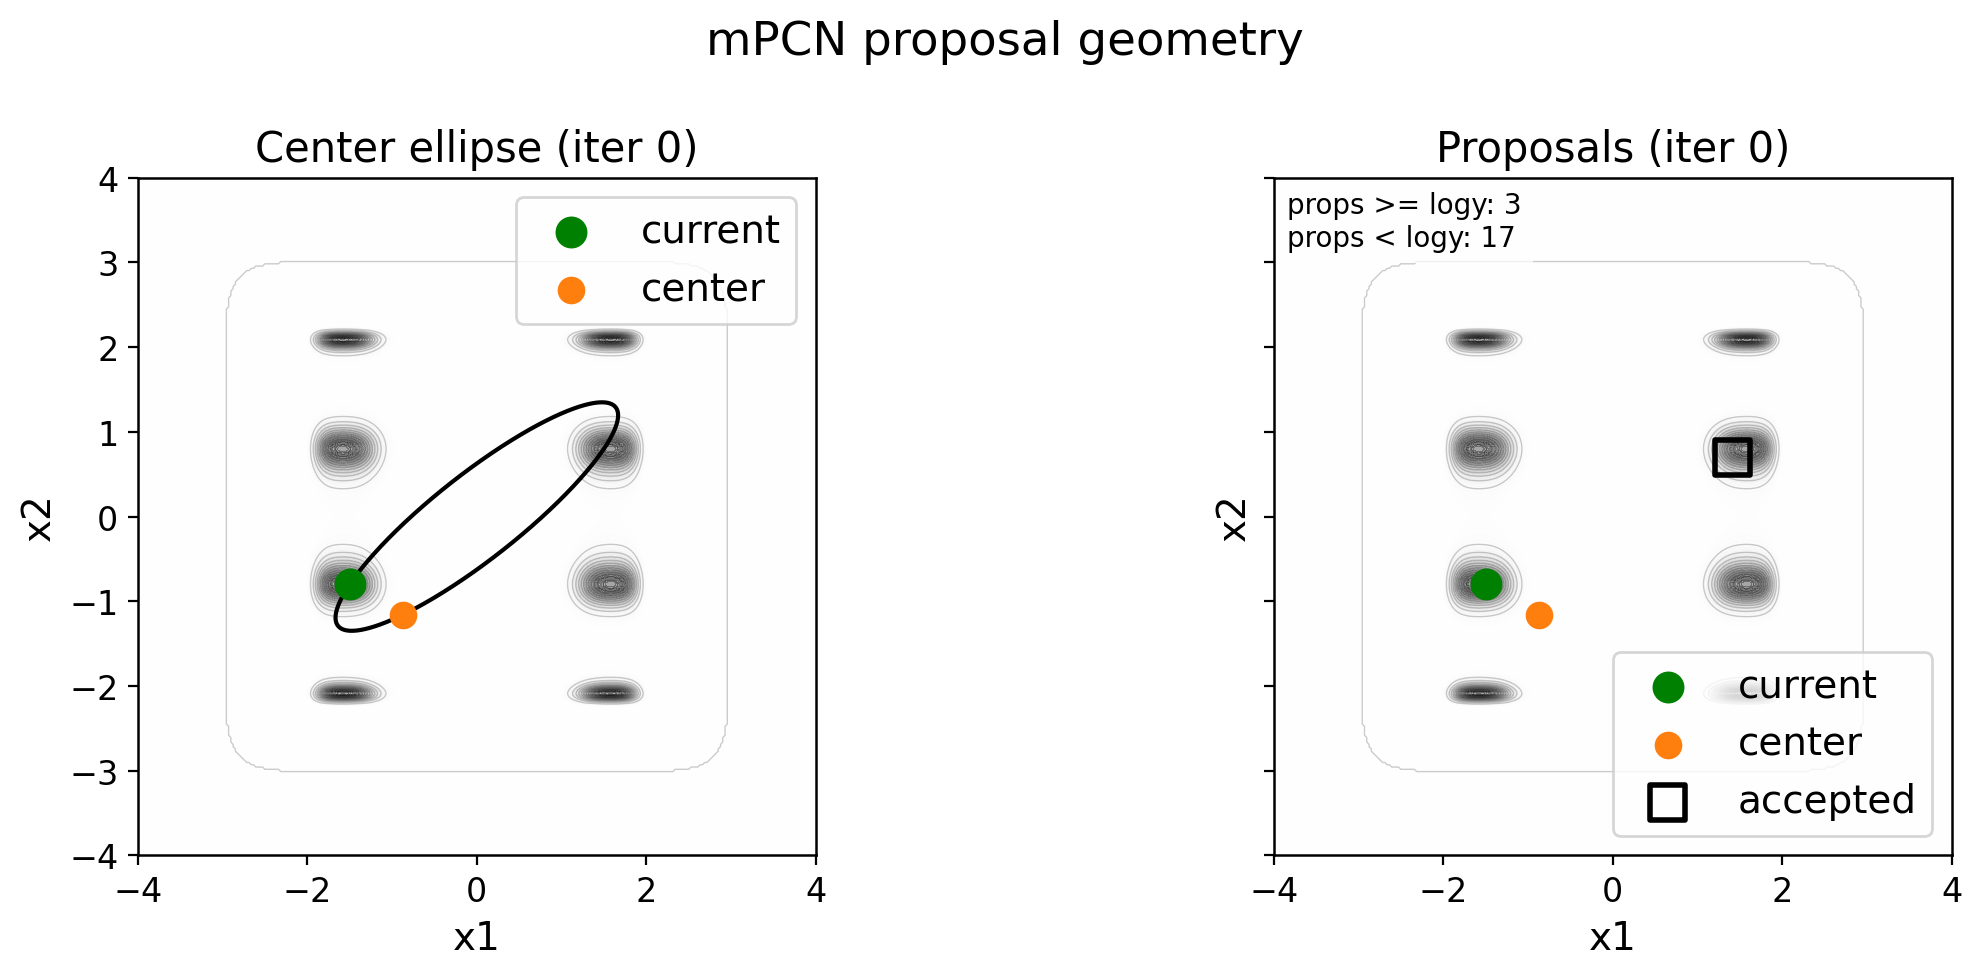

In [19]:
# Proposal illustrations for selected iterations (separate diagnostic run)
show_proposal_clouds = False  # Toggle proposal scatter clouds
plot_iters = [0] if not show_proposal_clouds else [nr for nr in np.arange(0, 10000, 1000)]
plot_iters = sorted(set(plot_iters))
n_iters_diag = max(plot_iters) + 1
seed_mpcn_diag = 202
rng_diag = np.random.default_rng(seed_mpcn_diag)
x0_diag = x0.copy()

grid_min = -4.0
grid_max = 4.0
grid = np.linspace(grid_min, grid_max, 300)
X1, X2 = np.meshgrid(grid, grid)
log_like = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x_grid = np.array([X1[i, j], X2[i, j]])
        log_like[i, j] = log_likelihood_16polynomic(x_grid, y_obs, sigma=sigma_noise)
log_like -= log_like.max()
like_density = np.exp(log_like)

theta = np.linspace(0.0, 2.0 * np.pi, 800)
levels_fill = 50
levels_line = 14

def plot_mpcn_snapshot(iter_idx, x, x_center, nu_c, props, candidates, logy, accepted_idx):
    mu = problem.prior_mean()
    ellipse = mu + np.cos(theta)[:, None] * (x - mu) + np.sin(theta)[:, None] * nu_c
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    for ax in axes:
        ax.contourf(X1, X2, like_density, levels=levels_fill, cmap="Greys", alpha=0.35)
        ax.contour(X1, X2, like_density, levels=levels_line, colors="black", linewidths=0.5, alpha=0.2)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.grid(False)
    axes[0].plot(ellipse[:, 0], ellipse[:, 1], color="black", linewidth=1.5, zorder=2)
    axes[0].scatter([x[0]], [x[1]], color="green", s=110, marker="o", label="current", zorder=3)
    axes[0].scatter([x_center[0]], [x_center[1]], color="tab:orange", s=80, marker="o", label="center", zorder=3)
    axes[0].set_title(f"Center ellipse (iter {iter_idx})")
    axes[0].legend(loc="upper right")

    prop_log_like = np.array([problem.log_likelihood(p) for p in props])
    above = prop_log_like >= logy
    n_above = int(np.sum(above))
    n_below = int(props.shape[0] - n_above)
    axes[1].scatter([x[0]], [x[1]], color="green", s=110, marker="o", label="current", zorder=3)
    axes[1].scatter([x_center[0]], [x_center[1]], color="tab:orange", s=80, marker="o", label="center", zorder=3)
    if show_proposal_clouds:
        axes[1].scatter(props[~above, 0], props[~above, 1], color="teal", s=10, alpha=0.8, label="props < logy", zorder=2)
        axes[1].scatter(props[above, 0], props[above, 1], color="teal", s=10, alpha=0.8, label="props >= logy", zorder=2)
    accepted_point = candidates[accepted_idx]
    axes[1].scatter([accepted_point[0]], [accepted_point[1]], facecolors="none", edgecolors="black",
                    s=160, marker="s", linewidths=2.0, label="accepted", zorder=4)
    axes[1].text(
        0.02,
        0.98,
        f"props >= logy: {n_above}\nprops < logy: {n_below}",
        transform=axes[1].transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
    )
    axes[1].set_title(f"Proposals (iter {iter_idx})")
    axes[1].legend(loc="lower right")
    fig.suptitle("mPCN proposal geometry")
    fig.tight_layout()
    plt.show()

snapshots = {}
x = x0_diag.copy()
for t in range(n_iters_diag):
    log_l0 = problem.log_likelihood(x)
    logy = log_l0 + np.log(rng_diag.uniform())
    x_new, idx, diag = mpcn_step(
        x,
        problem,
        rng_diag,
        rho=rho,
        n_props=n_props,
        return_idx=True,
        return_diagnostics=True,
    )
    if t in plot_iters:
        snapshots[t] = (
            x.copy(),
            diag["x_center"].copy(),
            diag["nu_c"].copy(),
            diag["props"].copy(),
            diag["candidates"].copy(),
            logy,
            idx,
        )
    x = x_new

for t in plot_iters:
    x_snap, x_center_snap, nu_c_snap, props_snap, candidates_snap, logy_snap, idx_snap = snapshots[t]
    plot_mpcn_snapshot(t, x_snap, x_center_snap, nu_c_snap, props_snap, candidates_snap, logy_snap, idx_snap)

Saved /home/senng/multiproposal-internal/reports/multiwell/multiwell_mpcn_single_P20_rho0.1_iters20000_seed202_sigma1_prior1_h8f219f464fcc/likelihood_contours_multiwell_sigma1_prior1_grid300_seed202.png


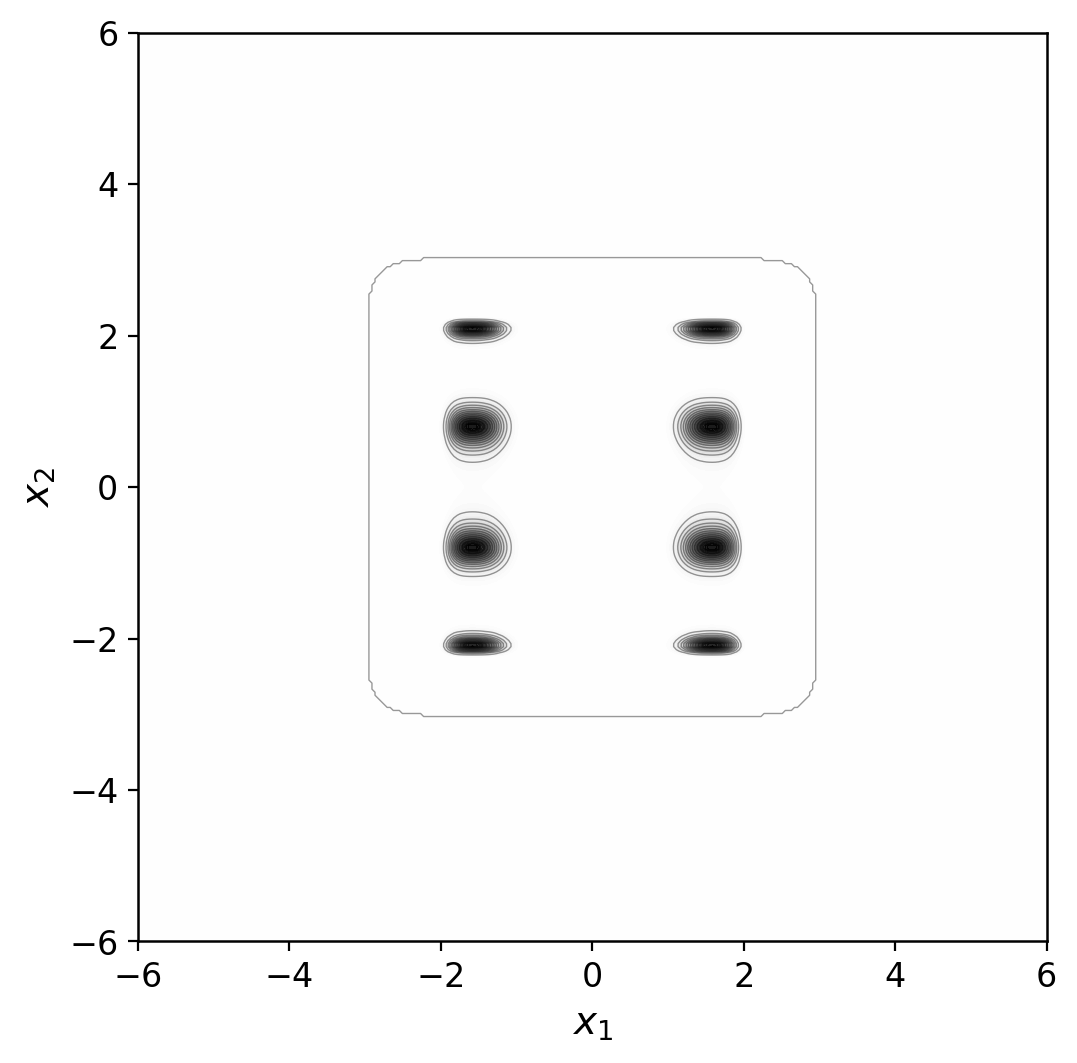

In [20]:
# Publication-quality likelihood contours (multiwell)
apply_pub_style()
reports_dir.mkdir(parents=True, exist_ok=True)

grid_min = -6.0
grid_max = 6.0
grid_n = 300
grid = np.linspace(grid_min, grid_max, grid_n)
X1, X2 = np.meshgrid(grid, grid)
log_like = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x_grid = np.array([X1[i, j], X2[i, j]])
        log_like[i, j] = log_likelihood_16polynomic(x_grid, y_obs, sigma=sigma_noise)
log_like -= log_like.max()
like = np.exp(log_like)

fig, ax = plt.subplots(1, 1, figsize=(6.5, 5.2), constrained_layout=True)
levels_fill = 50
levels_line = 14
ax.contourf(X1, X2, like, levels=levels_fill, cmap="Grays", alpha=0.9)
ax.contour(X1, X2, like, levels=levels_line, colors="black", linewidths=0.5, alpha=0.4)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
# ax.set_title("Multiwell likelihood contours")

def _fmt(val):
    return str(val).replace(".", "p")

config_tag = f"sigma{_fmt(sigma_noise)}_prior{_fmt(prior_std)}_grid{grid_n}_seed{seed_mcmc}"
fig_path = reports_dir / f"likelihood_contours_multiwell_{config_tag}.png"
fig.savefig(fig_path, bbox_inches="tight")
print(f"Saved {fig_path}")
plt.show()

In [21]:
# Runtime + ESS/MSJD per minute
burn_in_metric = 500
max_lag = 1500

def compute_msjd_per_param(chain):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    jumps = np.diff(chain, axis=0)
    msjd = np.mean(jumps * jumps, axis=0)
    return msjd

def compute_ess_per_param(chain, max_lag):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    variances = np.var(chain, axis=0)
    if np.all(variances == 0):
        return np.zeros(chain.shape[1])
    ess_vals = estimate_effective_sample_size(chain, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    ess_vals[variances == 0] = 0.0
    return ess_vals

def summarize_chain_metrics(chain, runtime_sec, label):
    post = chain[burn_in_metric:]
    ess_vals = compute_ess_per_param(post, max_lag=max_lag)
    msjd_vals = compute_msjd_per_param(post)
    ess_mean = float(np.nanmean(ess_vals)) if ess_vals.size else 0.0
    msjd_mean = float(np.nanmean(msjd_vals)) if msjd_vals.size else 0.0
    runtime_min = runtime_sec / 60.0
    ess_per_min = ess_mean / runtime_min if runtime_min > 0 else np.nan
    print(f"{label} runtime (min): {runtime_min:.2f}")
    print(f"{label} mean ESS: {ess_mean:.1f}")
    print(f"{label} mean MSJD: {msjd_mean:.4g}")
    print(f"{label} ESS per minute: {ess_per_min:.2f}")
    return {
        'runtime_sec': runtime_sec,
        'runtime_min': runtime_min,
        'ess_mean': ess_mean,
        'msjd_mean': msjd_mean,
        'ess_per_min': ess_per_min,
    }

metrics_mpcn = summarize_chain_metrics(chain_mpcn, runtime_mpcn_sec, 'mPCN')
metrics_pcn = None
if run_pcn and chain_pcn is not None:
    metrics_pcn = summarize_chain_metrics(chain_pcn, runtime_pcn_sec, 'pCN (chain 0)')
else:
    print('Skipping pCN metrics (run_pcn=False).')
metrics_mess = None
if run_mess and chain_mess is not None:
    metrics_mess = summarize_chain_metrics(chain_mess, runtime_mess_sec, 'MESS (M=5)')
else:
    print('Skipping MESS metrics (run_mess=False).')

run_dir = estimations_dir
with open(run_dir / 'metrics.json', 'w', encoding='utf-8') as f:
    json.dump({
        'mpcn': metrics_mpcn,
        'pcn': metrics_pcn,
        'mess': metrics_mess,
        'runtime_mpcn_sec': runtime_mpcn_sec,
        'runtime_pcn_sec': runtime_pcn_sec,
        'runtime_mess_sec': runtime_mess_sec,
        'accept_rate_pcn': accept_rate_pcn,
        'accept_rate_pcn_all': accept_rate_pcn_all,
        'num_ind_chains': num_ind_chains,
    }, f, indent=2)
print('Saved metrics to:', run_dir / 'metrics.json')

Estimating ESS for each parameter.
mPCN runtime (min): 0.07
mPCN mean ESS: 6770.4
mPCN mean MSJD: 1.666
mPCN ESS per minute: 101373.34
Estimating ESS for each parameter.
pCN (chain 0) runtime (min): 0.00
pCN (chain 0) mean ESS: 481.6
pCN (chain 0) mean MSJD: 0.1852
pCN (chain 0) ESS per minute: 97219.00
Estimating ESS for each parameter.
MESS (M=5) runtime (min): 0.02
MESS (M=5) mean ESS: 16983.4
MESS (M=5) mean MSJD: 2.814
MESS (M=5) ESS per minute: 1053653.32
Saved metrics to: /home/senng/multiproposal-internal/estimations/multiwell/multiwell_mpcn_single_P20_rho0.1_iters20000_seed202_sigma1_prior1_h8f219f464fcc/metrics.json


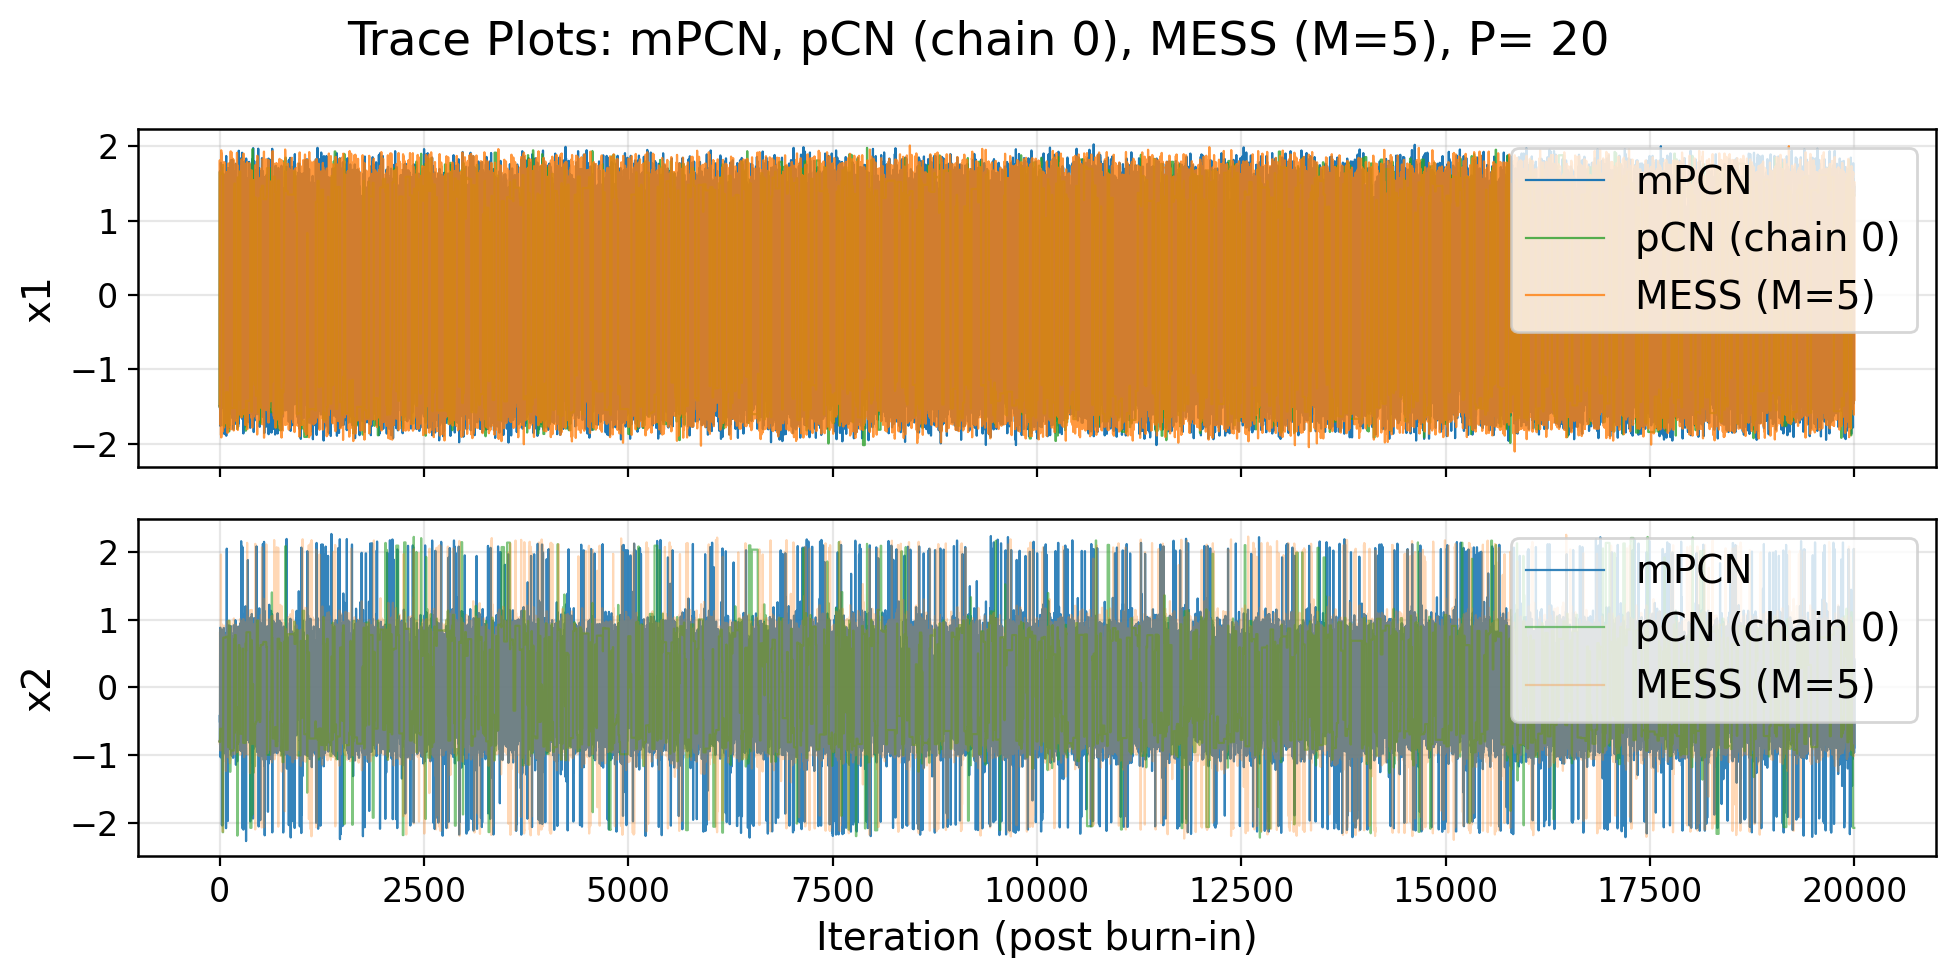

In [22]:
burn_in = 0
post_chain_mpcn = chain_mpcn[burn_in:]
post_chain_pcn = chain_pcn[burn_in:] if run_pcn and chain_pcn is not None else None
post_chain_mess = chain_mess[burn_in:] if run_mess and chain_mess is not None else None

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(post_chain_mpcn[:, 0], color='tab:blue', linewidth=0.8, label='mPCN')
if post_chain_pcn is not None:
    axes[0].plot(post_chain_pcn[:, 0], color='tab:green', linewidth=0.8, alpha=0.8, label='pCN (chain 0)')
if post_chain_mess is not None:
    axes[0].plot(post_chain_mess[:, 0], color='tab:orange', linewidth=0.8, alpha=0.8, label='MESS (M=5)')
axes[0].set_ylabel('x1')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='upper right')

axes[1].plot(post_chain_mpcn[:, 1], color='tab:blue', linewidth=0.8, alpha=0.9, label='mPCN')
if post_chain_pcn is not None:
    axes[1].plot(post_chain_pcn[:, 1], color='tab:green', linewidth=0.8, alpha=0.6, label='pCN (chain 0)')
if post_chain_mess is not None:
    axes[1].plot(post_chain_mess[:, 1], color='tab:orange', linewidth=0.8, alpha=0.3, label='MESS (M=5)')
axes[1].set_ylabel('x2')
axes[1].set_xlabel('Iteration (post burn-in)')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='upper right')

title_parts = ['mPCN']
if post_chain_pcn is not None:
    title_parts.append('pCN (chain 0)')
if post_chain_mess is not None:
    title_parts.append('MESS (M=5)')
fig.suptitle(f"Trace Plots: {', '.join(title_parts)}, P= {n_props}")
fig.tight_layout()
plt.show()

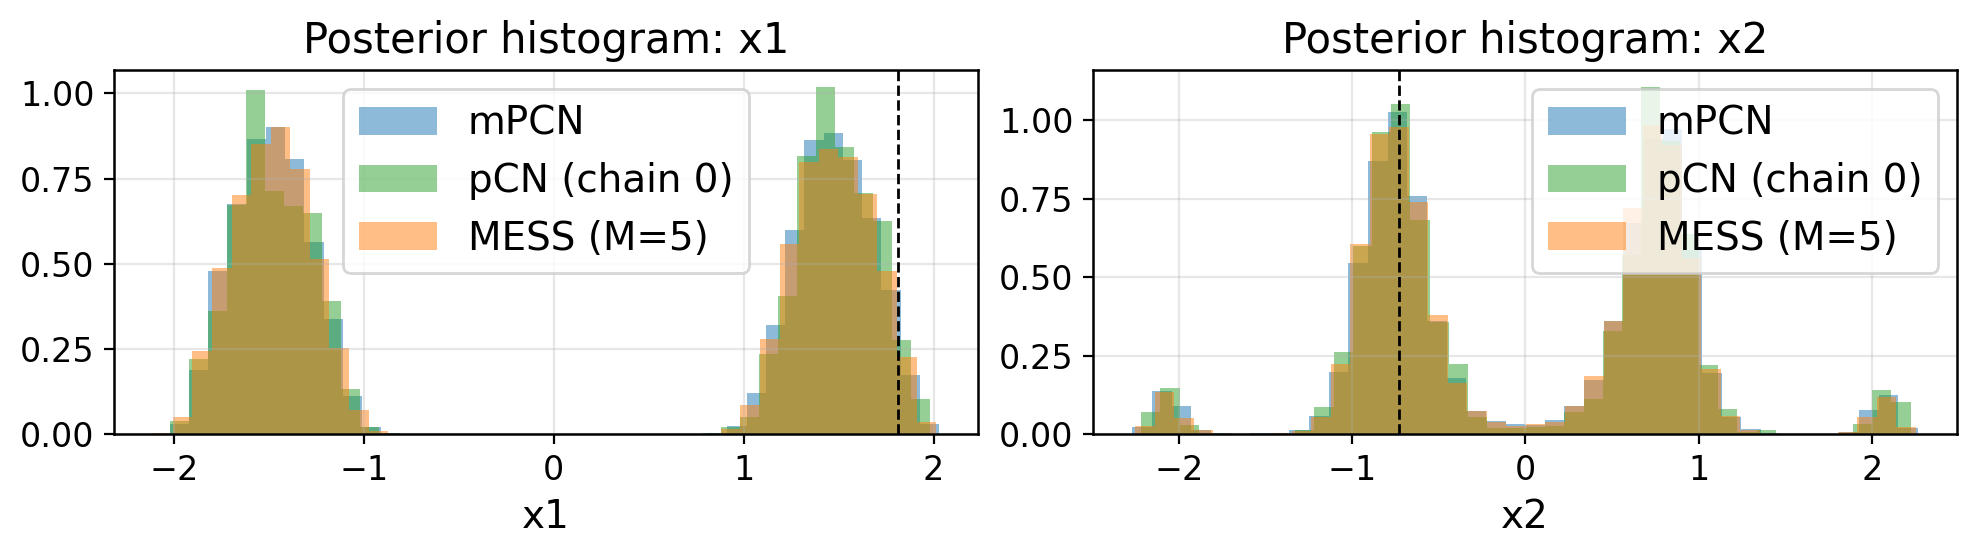

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
bins = 40
axes[0].hist(post_chain_mpcn[:, 0], bins=bins, density=True, color='tab:blue', alpha=0.5, label='mPCN')
if post_chain_pcn is not None:
    axes[0].hist(post_chain_pcn[:, 0], bins=bins, density=True, color='tab:green', alpha=0.5, label='pCN (chain 0)')
if post_chain_mess is not None:
    axes[0].hist(post_chain_mess[:, 0], bins=bins, density=True, color='tab:orange', alpha=0.5, label='MESS (M=5)')
axes[0].axvline(prior_sample[0], color='black', linestyle='--', linewidth=1)
axes[0].set_title('Posterior histogram: x1')
axes[0].set_xlabel('x1')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='best')

axes[1].hist(post_chain_mpcn[:, 1], bins=bins, density=True, color='tab:blue', alpha=0.5, label='mPCN')
if post_chain_pcn is not None:
    axes[1].hist(post_chain_pcn[:, 1], bins=bins, density=True, color='tab:green', alpha=0.5, label='pCN (chain 0)')
if post_chain_mess is not None:
    axes[1].hist(post_chain_mess[:, 1], bins=bins, density=True, color='tab:orange', alpha=0.5, label='MESS (M=5)')
axes[1].axvline(prior_sample[1], color='black', linestyle='--', linewidth=1)
axes[1].set_title('Posterior histogram: x2')
axes[1].set_xlabel('x2')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='best')

fig.tight_layout()
plt.show()

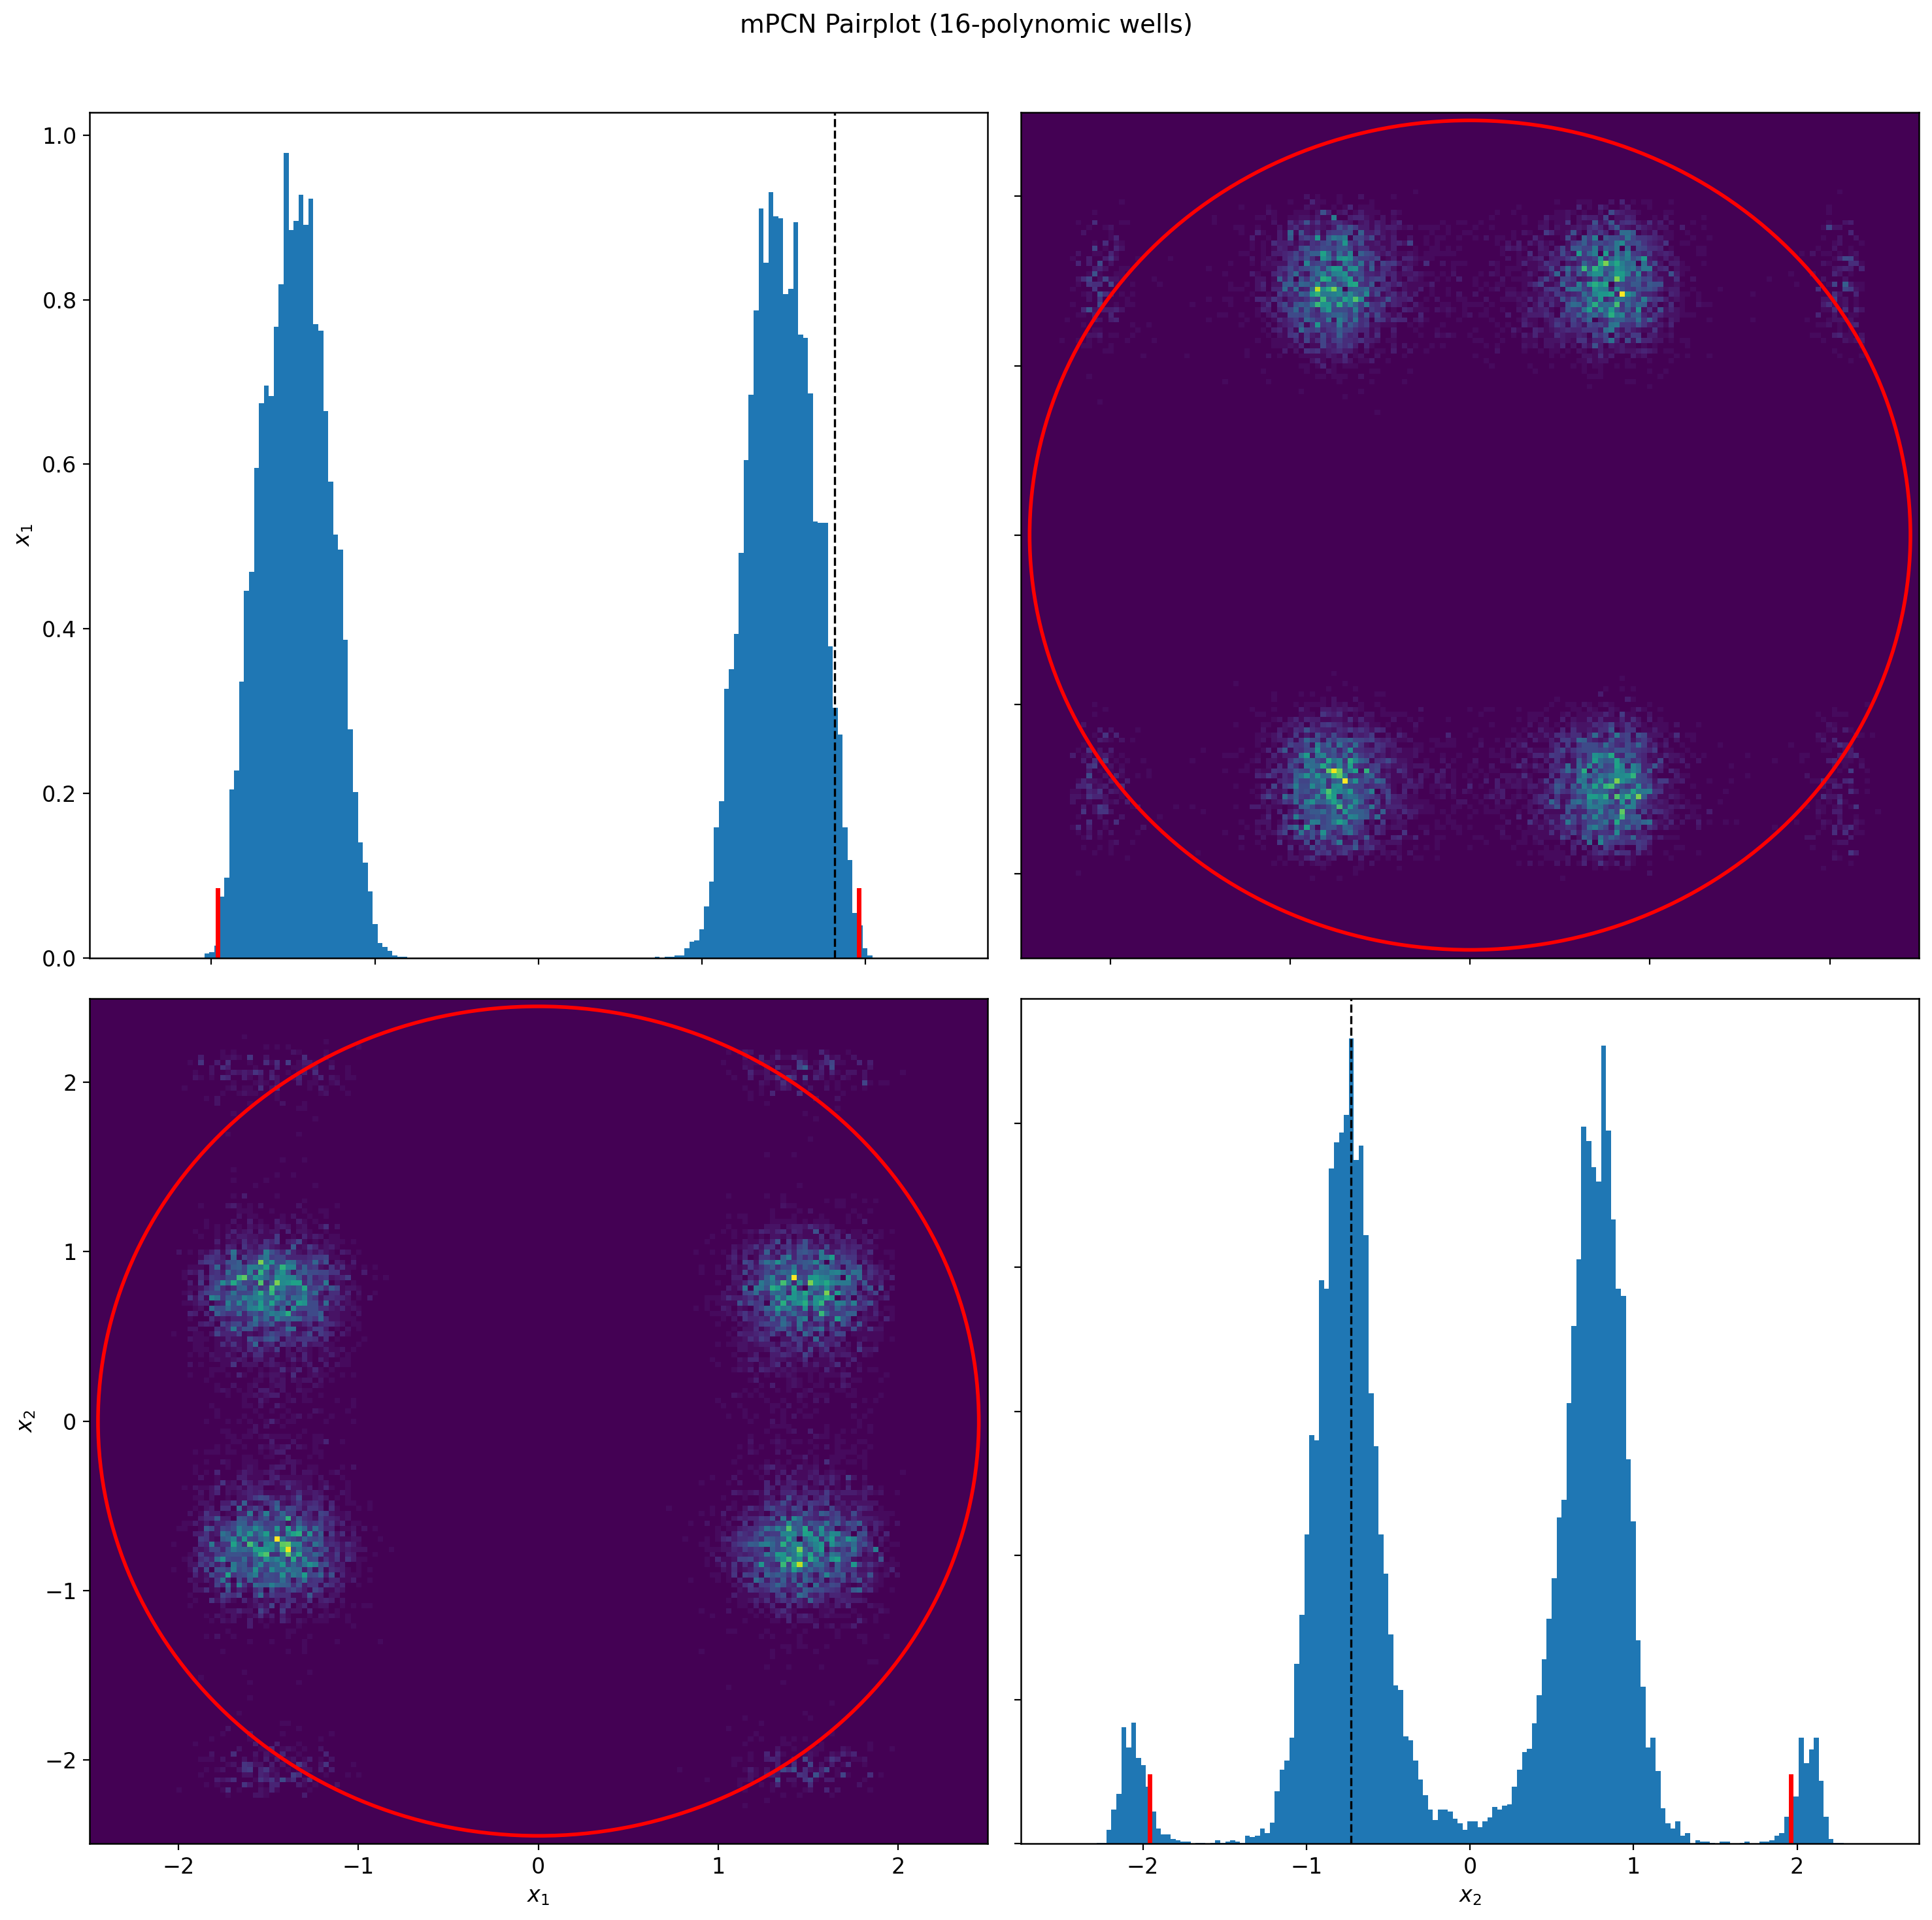

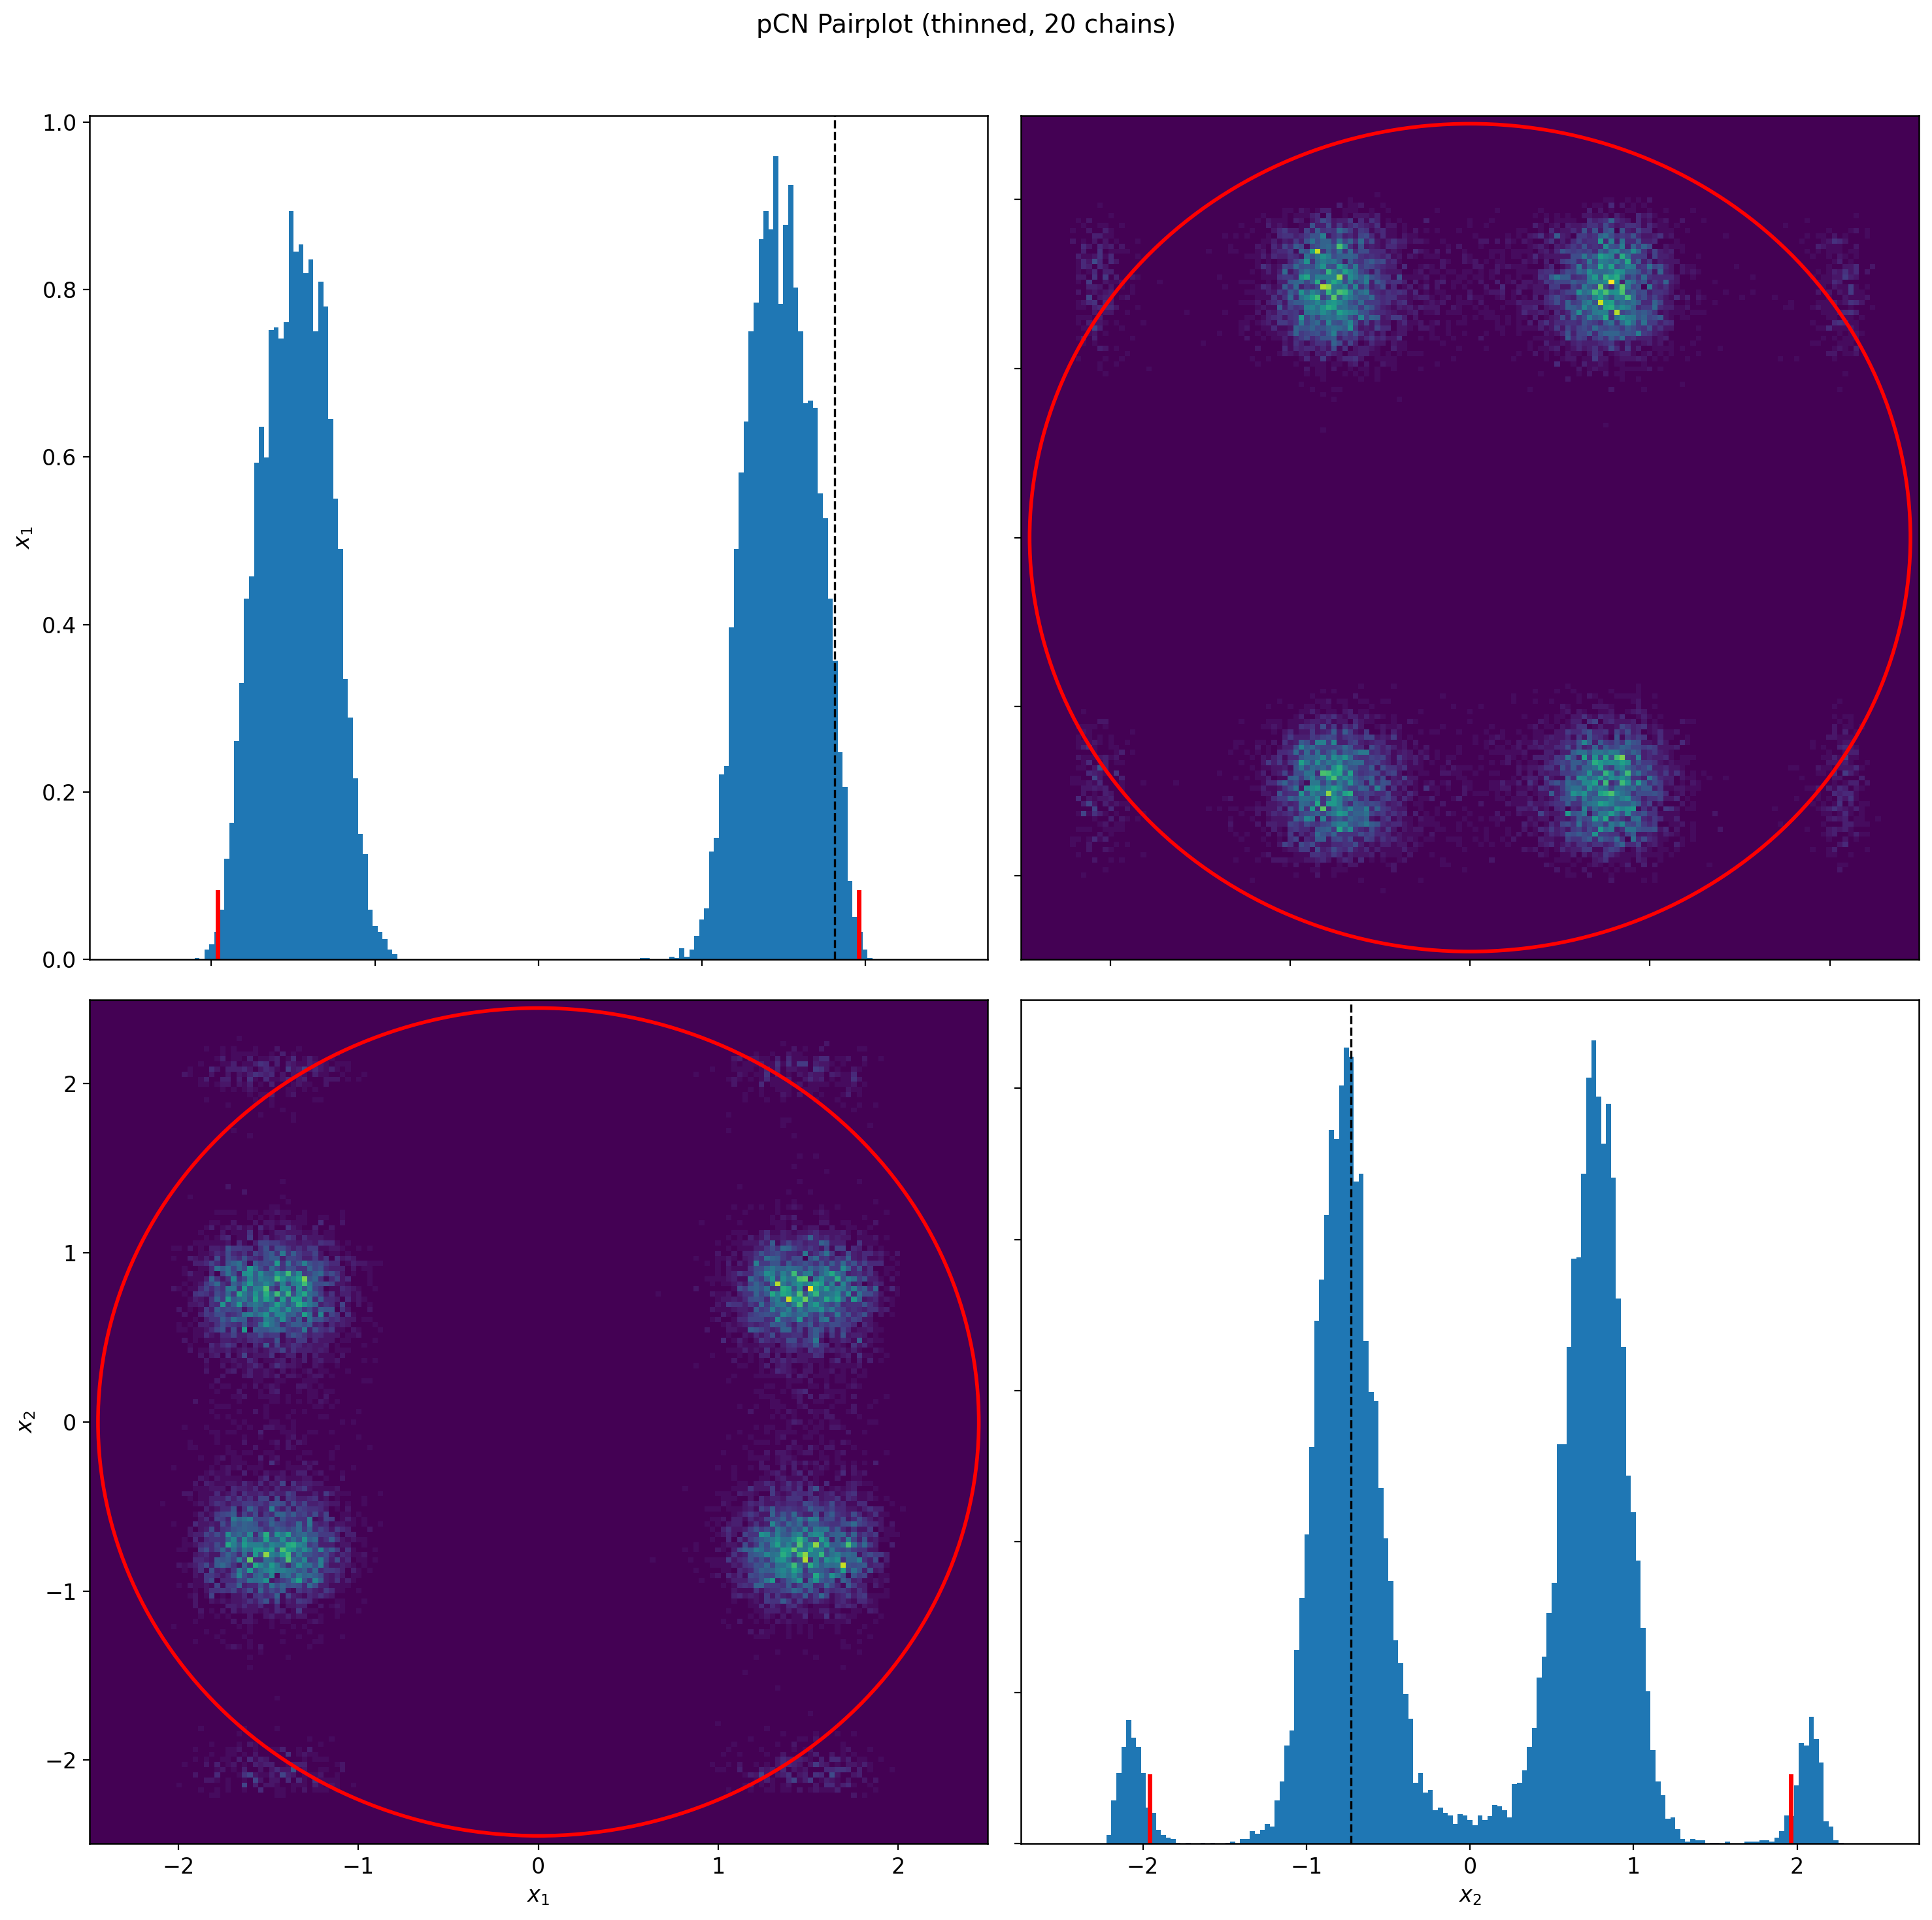

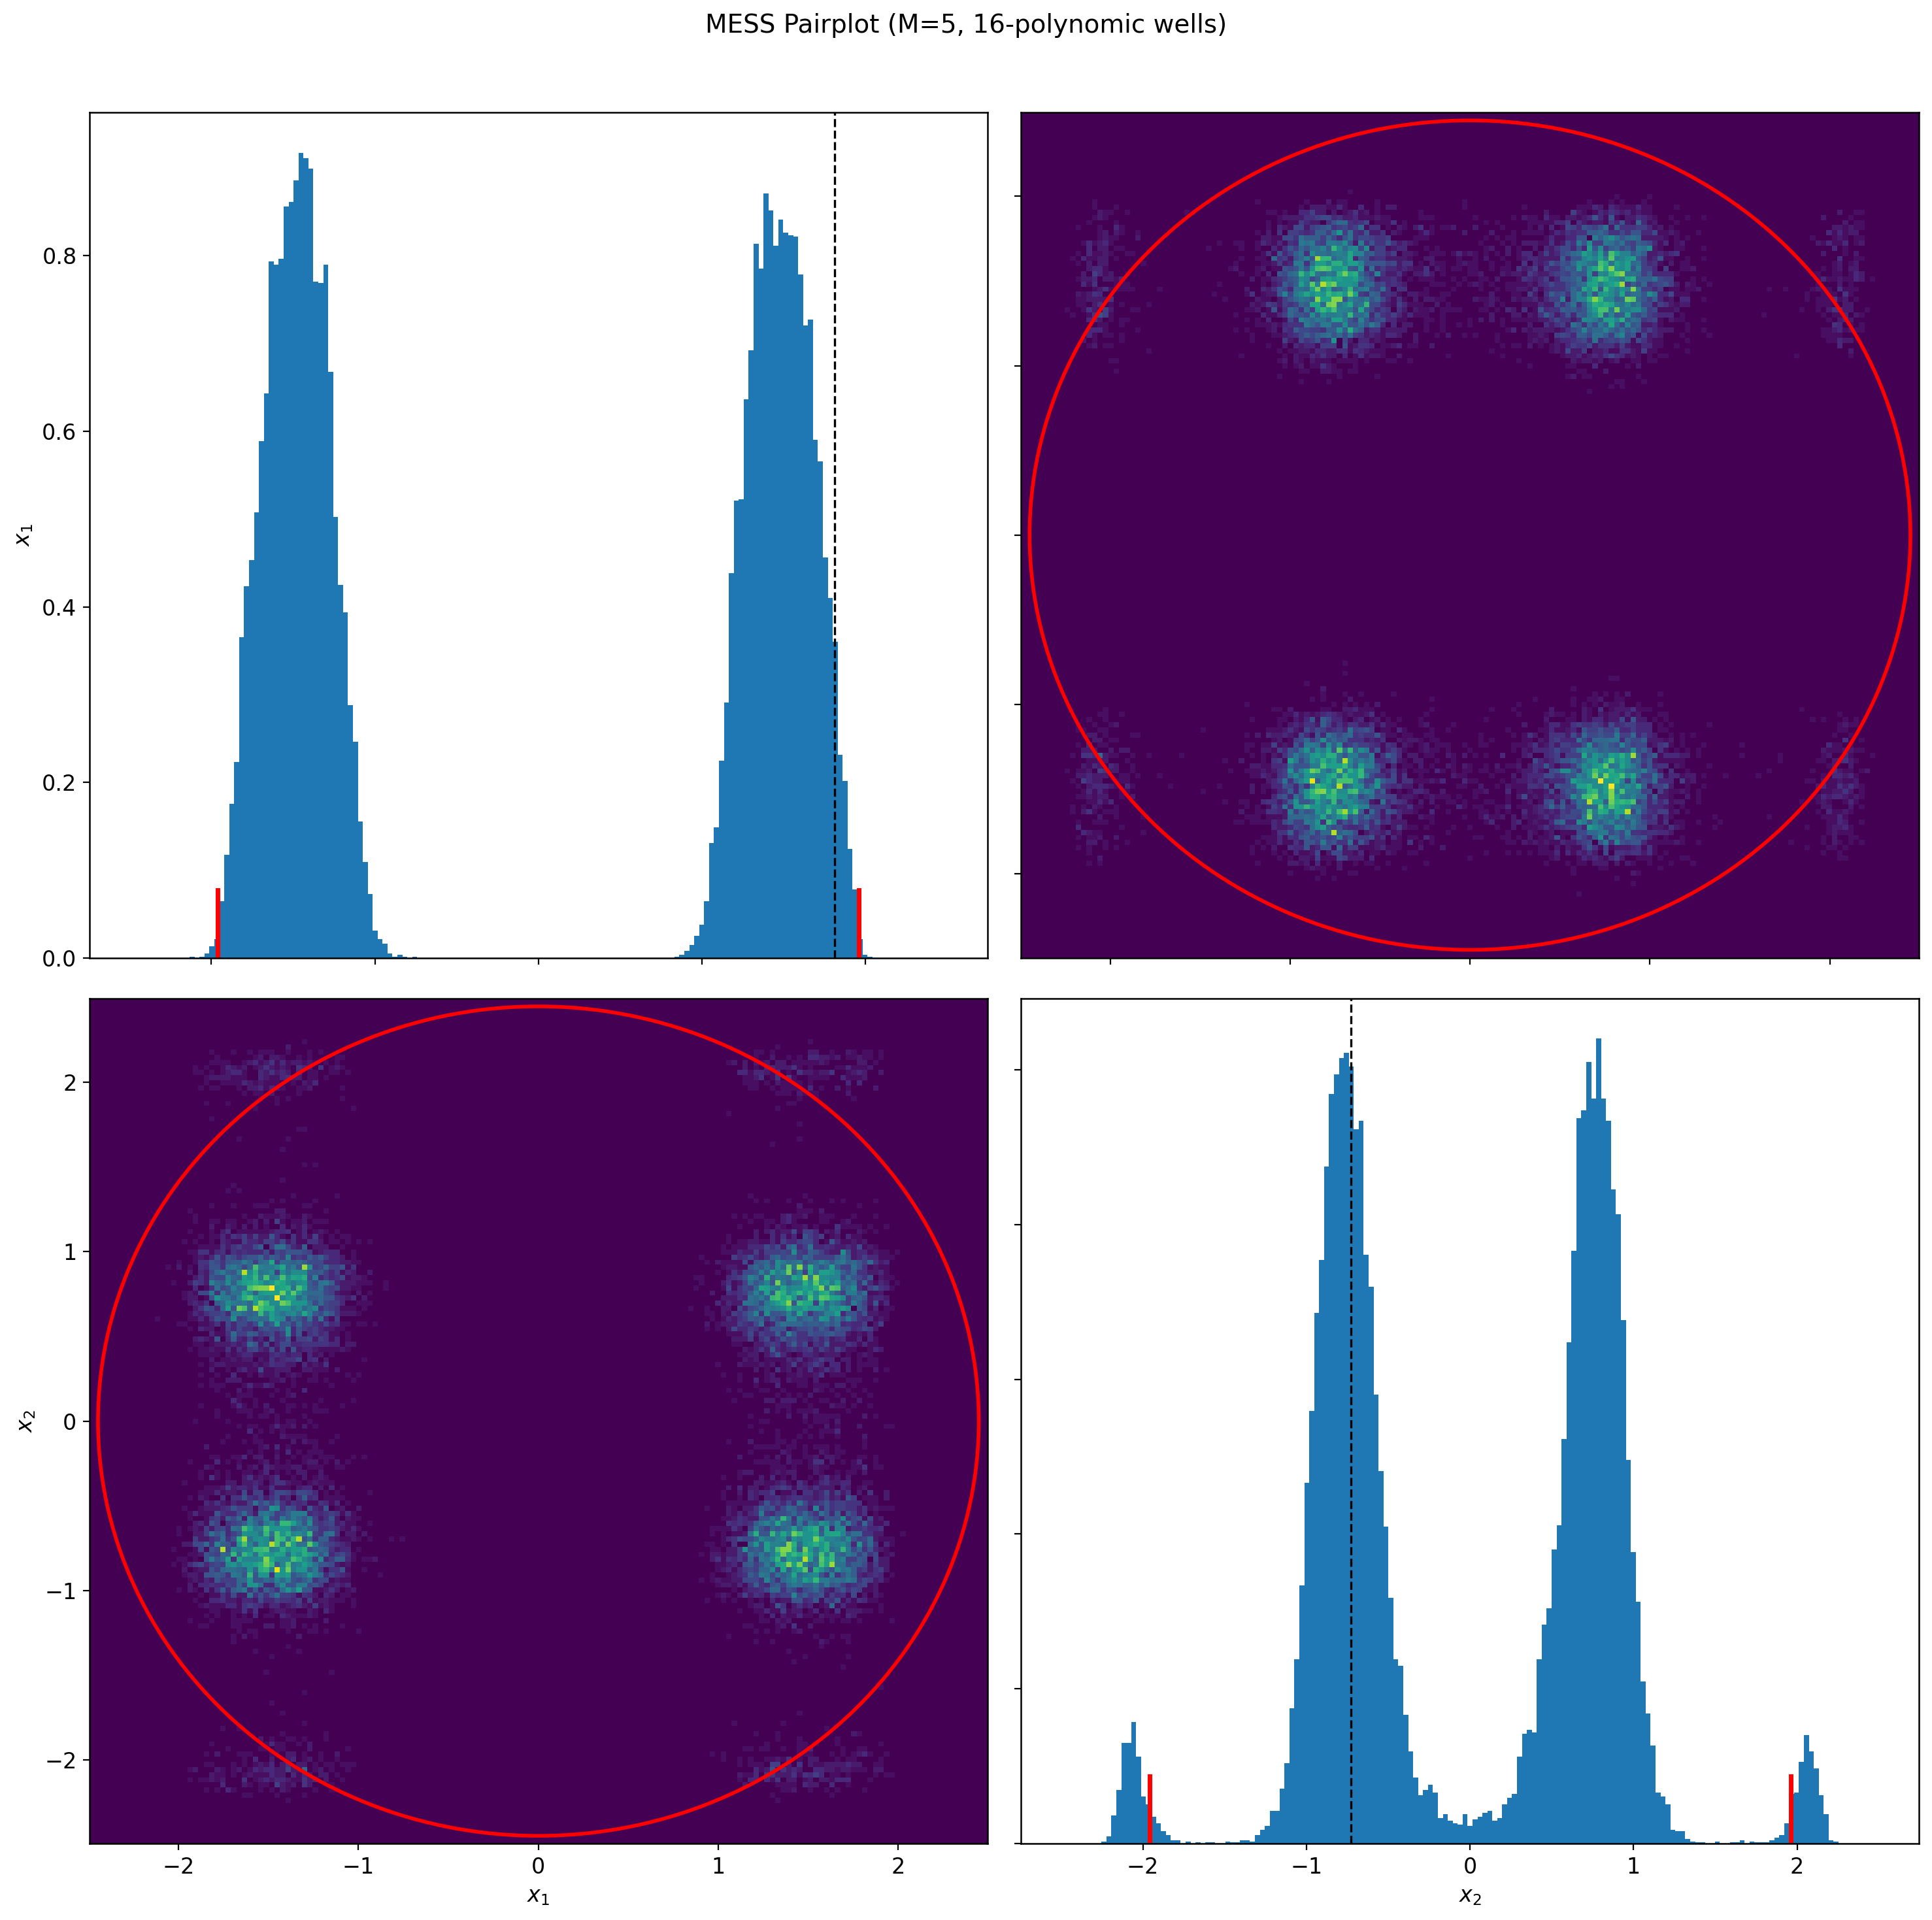

In [24]:
pcn_pair_samples = None
if run_pcn and pcn_chains is not None:
    pcn_pair_samples = np.vstack(
        [chain[burn_in::pcn_thin_step] for chain in pcn_chains]
    )

combined_list = [post_chain_mpcn]
if pcn_pair_samples is not None:
    combined_list.append(pcn_pair_samples)
if post_chain_mess is not None:
    combined_list.append(post_chain_mess)
combined = np.vstack(combined_list)
R = 1.1 * np.max(np.abs(combined))
dr = 0.03

_ = make_hist_grid_comps(
    R=R,
    dr=dr,
    samples=post_chain_mpcn,
    comp_list=[0, 1],
    save_path=None,
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map={0: '$x_1$', 1: '$x_2$'},
    font_size=12,
    title='mPCN Pairplot (16-polynomic wells)',
    true_values=prior_sample,
 )

if pcn_pair_samples is not None:
    _ = make_hist_grid_comps(
        R=R,
        dr=dr,
        samples=pcn_pair_samples,
        comp_list=[0, 1],
        save_path=None,
        C=prior_cov,
        beta=0.95,
        hide_plot=False,
        label_map={0: '$x_1$', 1: '$x_2$'},
        font_size=12,
        title=f'pCN Pairplot (thinned, {num_ind_chains} chains)',
        true_values=prior_sample,
    )

if post_chain_mess is not None:
    _ = make_hist_grid_comps(
        R=R,
        dr=dr,
        samples=post_chain_mess,
        comp_list=[0, 1],
        save_path=None,
        C=prior_cov,
        beta=0.95,
        hide_plot=False,
        label_map={0: '$x_1$', 1: '$x_2$'},
        font_size=12,
        title='MESS Pairplot (M=5, 16-polynomic wells)',
        true_values=prior_sample,
    )

In [25]:
# Results are saved earlier in the notebook.
print('Samples saved to:', estimations_dir / 'samples.npz')
print('Metrics saved to:', estimations_dir / 'metrics.json')

Samples saved to: /home/senng/multiproposal-internal/estimations/multiwell/multiwell_mpcn_single_P20_rho0.1_iters20000_seed202_sigma1_prior1_h8f219f464fcc/samples.npz
Metrics saved to: /home/senng/multiproposal-internal/estimations/multiwell/multiwell_mpcn_single_P20_rho0.1_iters20000_seed202_sigma1_prior1_h8f219f464fcc/metrics.json
